# Augmented Linear Mixing Model (ALMM)

Everything here needs testing

In [121]:
# Import necessary packages and libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
import graphlearning as gl
from scipy.special import jn
import scipy.sparse as sps
import scipy.sparse.linalg as spla
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.ndimage import gaussian_filter
from itertools import product
from joblib import Parallel, delayed
from scipy.optimize import nnls

# Import functions from Chen et. al.
from graph_active_learning_functions import *

# Example usage
# vca = eea.VCA()
# endmembers, indices, projected = vca.extract(data, num_endmembers)

In [122]:
# Note: This code was generated by Claude, not 100% sure it is accurate

def vca(X, R = 2, snr_input=0):
    """
    Finds the endmembers in a sample X.

    Parameters:
    X (numpy.ndarray): Unlabeled data matrix (p, N).
    R (integer): Number of endmembers.
    """
    p, N = X.shape

    # SNR estimation and projection method selection
    X_m = np.mean(X, axis=1, keepdims=True)
    X_o = X - X_m

    Ud, Sd, _ = np.linalg.svd(X_o @ X_o.T / N)
    Ud = Ud[:, :R]

    x_p = Ud.T @ X_o

    P_X = np.sum(X ** 2) / N
    P_x = np.sum(x_p ** 2) / N + np.sum(X_m ** 2)

    if snr_input == 0:
        snr_est = 10 * np.log10((P_x - R / p * P_X) / (P_X - P_x + 1e-12))
    else:
        snr_est = snr_input

    snr_th = 15 + 10 * np.log10(R)

    # Project onto R-dimensional subspace
    if snr_est < snr_th:
        d = R - 1
        Ud = Ud[:, :d]
        Xp = Ud @ x_p[:d, :] + X_m
        x = x_p[:d, :]
        c = np.sqrt(np.max(np.sum(x ** 2, axis=0)))
        X = np.vstack([x, c * np.ones((1, N))])
    else:
        d = R
        Ud, Sd, _ = np.linalg.svd(X @ X.T / N)
        Ud = Ud[:, :d]
        x_p = Ud.T @ X
        Xp = Ud @ x_p[:d, :]
        x = Ud.T @ X
        u = np.mean(x, axis=1, keepdims=True)
        X = x / np.sum(x * u, axis=0, keepdims=True)

    indices = np.zeros(R, dtype=int)
    A = np.zeros((R, R))
    A[-1, 0] = 1

    # Iterative vertex search
    for i in range(R):
        w = np.random.rand(R, 1)
        f = w - A @ np.linalg.pinv(A) @ w
        f = f / np.linalg.norm(f)

        v = f.T @ X
        idx = np.argmax(np.abs(v))

        A[:, i] = X[:, idx]
        indices[i] = idx

    S = Xp[:, indices]

    return S, indices, Xp

In [123]:
def NNLS(X, S):
    """
    Nonnegative Least Squares to solve for A (abundance matrix).
    
    X (numpy.ndarray): Unlabeled data matrix (p, N).
    S (numpy.ndarray): End-member spectrum matrix (p, q) (can be obtained via VCA, but must average it)
    Returns: phi (N, R) - abundance for each pixel/endmember
    """
    p, N = X.shape
    q = S.shape[1]
    phi = np.zeros((N, q))
    for i in range(N):
        a, _ = nnls(S, X[:, i])
        phi[i, :] = a
    return phi

In [124]:
# Code also generated by Claude, double check
# Based on algorithm proposed by ELMM
# Run NCLSU on S, which includes scaling factors
# Return an estimation of A

def SCLSU(X, S):

    # Run NCLSU
    phi = NNLS(X, S)

    # Get the scaling factor
    psi_hat = phi.sum(axis = 1)

    # Sum to one condition
    A_est = phi / psi_hat[:, None]

    # Return the estimation of A
    return A_est.T

In [125]:
# Algorithm 1: ALMM-Based Pixel-Wise SU 

def algo_1_almm():
    """
    Note: x_k = y_k, S = A, A = X, T = S in paper.

    Outputs a_k, t_k, b_k.
    Parameters:

    """
    # TODO
    return 0

In [ ]:
# Algorithm 2: ALMM-Based SVDL

def algo_2_almm(X, S, alpha, beta, gamma, eta, maxIter):
    """
    Note: X = Y, S = A, A = X, T = S, U = T, and p = D, q = P in paper. 
    A is (q, N). T is (N, N), AT is (q, N). E is (p, L). B is (L, N)
    (L is half the spectral length (p), so L = p/2)

    Parameters:
    X (numpy.ndarray): Unlabeled data matrix (p, N).
    S (numpy.ndarray): End-member spectrum matrix (p, q) (can be obtained via VCA, but must average it)
    alpha (float):
    beta (float):
    gamma (float):
    eta (float):
    max_iters (int):

    Returns:
    E (numpy.ndarray): Spectral variability matrix (p, L).
    A (numpy.ndarray): Abundance matrix (q, N).
    T (numpy.ndarray): Scalar variability matrix (N, N).
    B (numpy.ndarray): Coefficient matrix for E (L, N).
    
    """
    p, N = X.shape
    p, q = S.shape
    L = int(p/2)

    # Initialize variables (A^0 is generated by SCLSU, E^0 is random but switch to S_GLU - vca(X))

    # Initialize G = H = M to 0
    # T = I * originally S
    # B = 0
    # Delta = 0
    # Lambda = V = Omega = 0
    # Q = 0
    # U = 0 * originally T
    # Pi = 0
    # A = SCLSU * originally  X
    # E = S_GLU - vca(X)
    G = np.zeros((q, N))
    H = np.copy(G)
    M = np.copy(G)

    T = np.eye(N)
    B = np.zeros((L, N))

    Delta = np.zeros((N, N)) # associated with T and U
    Lambda = np.zeros((q, N)) # associated with X and G
    Upsilon = np.copy(Lambda) # associated with X and H
    Omega = np.copy(Lambda) # associated with XS and M

    Q = np.zeros((p, L)) # associated with E
    U = np.zeros((N, N)) # associated with T and U
    
    Pi = np.zeros((p, L)) # associaed with E and Q

    # TODO Initialize E using observed - library = S_GLU - vca(X). 
    # E can just also be some random orthogonal matrix
    A = SCLSU(X, S)

    # Generate random orthogonal matrix for E (change later possibly)
    np.random.seed(42)
    random_matrix = np.random.randn(p, L)
    E, _ = np.linalg.qr(random_matrix) # QR decomposition, E guaranteed to be orthogonal


    # Note: this doesn't work because we don't have access to A_gt, unless we call this function using a third party
    # pipeline function, which I'm not sure if it is correct.
    #
    # G, W = build_custom_knn_graph(X.T, K=int(N*0.005))
    # labeled_indices = algo_1_active_learning(X, W, m_initial=2, M_total=int(0.004*N), num_eigs=int(N*0.005))
    # X_hat = X[:, labeled_indices]
    # A_hat_exact = A_gt[:, labeled_indices]
    # A_hat_OH = generate_one_hot_labels(A_hat_exact)
    # _, S_GLU = algo_2_glu(X, X_hat, A_hat_OH, alpha, k=k)

    # Initialize scalars
    t = 0
    xi = 1e-3
    xi_max = 1e6 # this might need to chnage, it is blowing up the RMSE, or lower rho
    rho = 1.5
    epsilon = 1e-6
    converged = False

    # Define constants
    xi_I_q = xi * np.eye(q)   # for M subproblem
    xi_I_N = xi * np.eye(N)   # for A and T subproblems
    xi_I_L = xi * np.eye(L)   # for E subproblem
    xi_I_p = xi * np.eye(p)   # for Q subproblem
    beta_I = beta * np.eye(L) # for B subproblem

    # Begin iteration loop
    while (not converged) and t < maxIter:

        # Update matrices and their auxiliary variables
        
        # M subproblem (fix E, B, A, T)
        term1_M = np.linalg.inv((S.T @ S) + xi_I_q)
        term2_M = (S.T @ X) - (S.T @ E @ B) + (xi * (A @ T)) - Omega
        M_new = term1_M @ term2_M

        # B subproblem (fix E, M_new)
        term1_B = np.linalg.inv((E.T @ E) + beta_I)
        term2_B = (E.T @ X) - (E.T @ S @ M_new)
        B_new = term1_B @ term2_B

        # A subproblem (fix G, H, T, M_new, Lambda, Upsilon)
        term1_A = (xi * G) + Lambda + (xi * H) + Upsilon + (Omega @ T.T) + (xi * M_new @ T.T)
        term2_A = np.linalg.inv((xi * T @ T.T) + (2 * xi_I_N))
        A_new = term1_A @ term2_A
        #print(f"t={t}, xi={xi:.6f}, A_new min/max=({A_new.min():.4f}, {A_new.max():.4f}), RMSE={np.linalg.norm(A_new - A):.4f}")
        A_new = A_new / (A_new.sum(axis=0, keepdims=True) + 1e-10) # Normalize A using Hadamard division

        # T subproblem (fix M_new, A_new, U, Pi, Delta)
        term1_T = np.linalg.inv((xi * A_new.T @ A_new) + xi_I_N)
        term2_T = (xi * A_new.T @ M) + (A_new.T @ Omega) + (xi * U) + Delta
        T_new = term1_T @ term2_T
        T_new = np.diag(np.diag(T_new))  # enforce scalar/diagonal structure

        # E subproblem (fix M_new, B_new, Q, Pi)
        term1_E = (X @ B_new.T) - (S @ M_new @ B_new.T) + (xi * Q) + Pi
        term2_E = np.linalg.inv((B_new @ B_new.T) + xi_I_L)
        E_new = term1_E @ term2_E

        # Q subproblem (fix E, Q, E_new, Pi)
        term1_Q = np.linalg.inv((gamma * S @ S.T) + (eta * Q @ Q.T) + xi_I_p)
        term2_Q = (eta * Q) + (xi * E) - Pi
        Q_new = term1_Q @ term2_Q

        # G subproblem (fix A_new, Lambda)
        term1_G = np.maximum(0, np.abs(A - (Lambda / xi)) - (alpha / xi))
        term2_G = np.sign(A - (Lambda / xi))
        G_new = term1_G * term2_G # Double check

        # H subproblem (fix A_new, Upsilon)
        H_new = np.maximum(0, A - (Upsilon / xi))

        # U subproblem (fix T_new, Delta)
        U_new = np.maximum(0, T - (Delta / xi))

        # AT subproblem (fix A_new, T_new)
        AT_new = A_new @ T_new

        # Update Lagrange multipliers
        Lambda_new = Lambda + xi * (G_new - A_new)
        Upsilon_new = Upsilon + xi * (H_new - A_new)
        Omega_new = Omega + xi * (M_new - AT_new)
        Pi_new = Pi + xi * (Q_new - E_new)
        Delta_new = Delta + xi * (U_new - T_new)


        # Update penalty parameter
        xi_new = min(rho * xi, xi_max)

        # Check convergence conditions
        if ((np.linalg.norm(G_new - A_new) < epsilon) and 
            (np.linalg.norm(H_new - A_new) < epsilon) and
            (np.linalg.norm(M_new - AT_new) < epsilon) and
            (np.linalg.norm(Q_new - E_new) < epsilon) and 
            (np.linalg.norm(U_new - T_new) < epsilon) and
            (np.linalg.norm(E_new - E) < epsilon)):

            converged = True
        
        # Else, start the next iteration
        else:
            # Update iteration count
            t += 1

            # Advance state
            # Normal variables and auxiliary counterparts
            M = M_new
            B = B_new
            A = A_new
            T = T_new
            E = E_new
            Q = Q_new
            G = G_new
            H = H_new
            U = U_new

            # Lagrange multipliers
            Lambda = Lambda_new
            Upsilon = Upsilon_new
            Omega = Omega_new
            Pi = Pi_new
            Delta = Delta_new
            xi = xi_new


        
    return E, A, T, B

# Quick Example

Borrowed from other notebook

In [127]:
# Generate Random data
samples = 2000 # N
channels = 300 # p
np.random.seed(42)

# Create random labels and abundance matrix
L = np.random.uniform(0,1,samples)
A = np.array([L,1-L])

# Smooth out the two spectras
s_1 = gaussian_filter(np.random.uniform(0,1,channels),2)
s_2 = gaussian_filter(np.random.uniform(0,1,channels),2)

S_T = np.array([s_1,s_2])

S = S_T.T


# Create the linear mixing model
X=S@A
error_std = 0.05

E = np.random.normal(loc=0.0, scale=error_std, size=X.shape)

X=X+E

# Pick some parameter
alpha = 2e-3
beta = 2e-3
gamma = 5e-3
eta = 5e-3
maxIter = 30

# Run the algorithm on chosen parameters
E_f, A_f, T_f, B_f =  algo_2_almm(X, S, alpha, beta, gamma, eta, maxIter)



t=0, xi=0.001000, A_new min/max=(-0.0110, 0.3416), RMSE=24.4230
t=1, xi=0.001500, A_new min/max=(0.0001, 0.2499), RMSE=27.4902
t=2, xi=0.002250, A_new min/max=(-0.1229, 0.3608), RMSE=30.6384
t=3, xi=0.003375, A_new min/max=(-1.4386, 0.5106), RMSE=71.7509
t=4, xi=0.005063, A_new min/max=(-0.8647, 0.3323), RMSE=55.8637
t=5, xi=0.007594, A_new min/max=(-0.8906, 0.3360), RMSE=56.3705
t=6, xi=0.011391, A_new min/max=(-1.0086, 0.3773), RMSE=59.0099
t=7, xi=0.017086, A_new min/max=(-0.9601, 0.3543), RMSE=57.9720
t=8, xi=0.025629, A_new min/max=(-1.0057, 0.3632), RMSE=59.0878
t=9, xi=0.038443, A_new min/max=(-0.9831, 0.3433), RMSE=58.7103
t=10, xi=0.057665, A_new min/max=(-0.9747, 0.3224), RMSE=58.7355
t=11, xi=0.086498, A_new min/max=(-0.9376, 0.2835), RMSE=58.2163
t=12, xi=0.129746, A_new min/max=(-0.9033, 0.2447), RMSE=57.6766
t=13, xi=0.194620, A_new min/max=(-0.8232, 0.1635), RMSE=56.8085
t=14, xi=0.291929, A_new min/max=(-0.7686, 0.1113), RMSE=55.7922
t=15, xi=0.437894, A_new min/max=(-0

In [128]:
print(RMSE(A_f, A))
print("A_f min/max:", A_f.min(), A_f.max())
print("A_f col sums (should be ~1):", A_f.sum(axis=0)[:10])
print("Any NaN:", np.isnan(A_f).any())
print("Any huge values:", np.abs(A_f).max())

155176.58383050255
A_f min/max: -1551.2707565465591 1552.2707565465575
A_f col sums (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Any NaN: False
Any huge values: 1552.2707565465575


/var/folders/tj/yfk52qtn29v6xfdx45qkcclm0000gn/T/ipykernel_63694/3798989036.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


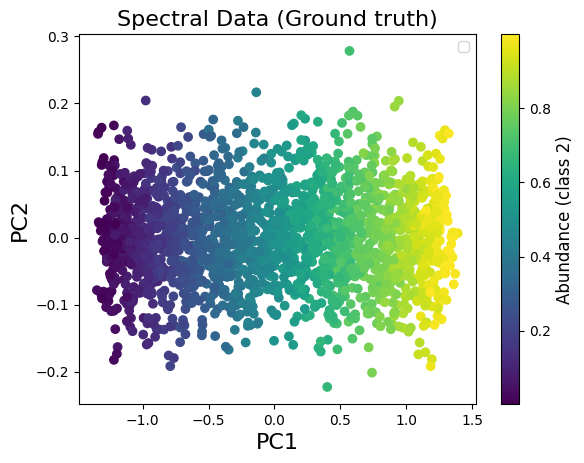

In [129]:
# Run PCA
from sklearn.decomposition import PCA

pca1 = PCA(n_components=2)
X_pca1 = pca1.fit_transform(X.T)

# Plot A (ground truth)
plt.scatter(X_pca1[:,0],X_pca1[:,1],c=A[0])

plt.title('Spectral Data (Ground truth)', fontsize = 16)
plt.xlabel('PC1', fontsize = 16)
plt.ylabel('PC2', fontsize = 16)
plt.legend()

cbar = plt.colorbar()
cbar.set_label('Abundance (class 2)', fontsize=12)

plt.show()

/var/folders/tj/yfk52qtn29v6xfdx45qkcclm0000gn/T/ipykernel_63694/3491217293.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


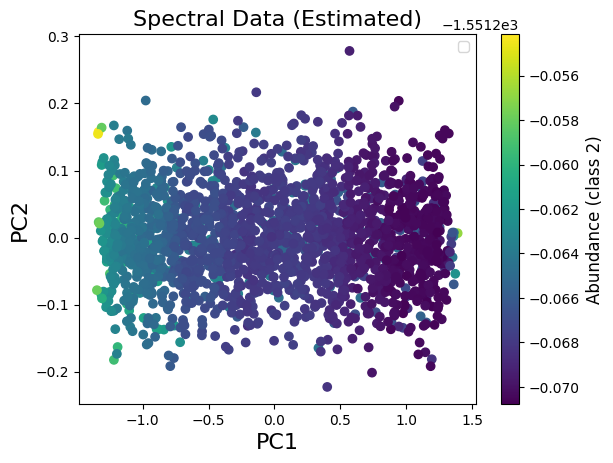

In [130]:
# Plot A (estimated)
plt.scatter(X_pca1[:,0],X_pca1[:,1],c=A_f[0])

plt.title('Spectral Data (Estimated)', fontsize = 16)
plt.xlabel('PC1', fontsize = 16)
plt.ylabel('PC2', fontsize = 16)
plt.legend()

cbar = plt.colorbar()
cbar.set_label('Abundance (class 2)', fontsize=12)

plt.show()